## Customer Segmentation

### Import lib

In [158]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [159]:
df = pd.read_csv("../data/online_retail.csv")
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,12/1/2009 7:45,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,12/1/2009 7:45,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,12/1/2009 7:46,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,12/1/2009 7:46,3.75,13085.0,United Kingdom


### Data Preprocessing

In [160]:
print(df.shape)
print(df.columns)
df.info()

# Missing values
print(df.isnull().sum())

# Statistical summary
df.describe()

(1048575, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB
Invoice             0
StockCode           0
Description      4372
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236682
Country             0
dtype: int64


,Quantity,Price,Customer ID
count,1.048575e+06,1.048575e+06,811893.000000
mean,9.957525e+00,4.627346e+00,15324.712265
std,1.335187e+02,1.228024e+02,1697.033034
min,-7.421500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13971.000000
50%,3.000000e+00,2.100000e+00,15260.000000
75%,1.000000e+01,4.150000e+00,16795.000000
max,7.421500e+04,3.897000e+04,18287.000000


In [161]:
df = df.dropna(subset=['Customer ID'])

In [162]:
df = df.drop_duplicates()

In [163]:
# remove negaive values
df = df[df['Quantity'] > 0]

df = df[df['Price'] > 0]

In [164]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [165]:
# create total price column
df['TotalPrice'] = df['Quantity'] * df['Price']

In [166]:
print(df.shape)
df.info()
df.head(10)

(767369, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 767369 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      767369 non-null  object        
 1   StockCode    767369 non-null  object        
 2   Description  767369 non-null  object        
 3   Quantity     767369 non-null  int64         
 4   InvoiceDate  767369 non-null  datetime64[ns]
 5   Price        767369 non-null  float64       
 6   Customer ID  767369 non-null  float64       
 7   Country      767369 non-null  object        
 8   TotalPrice   767369 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 58.5+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,45.0


### EDA

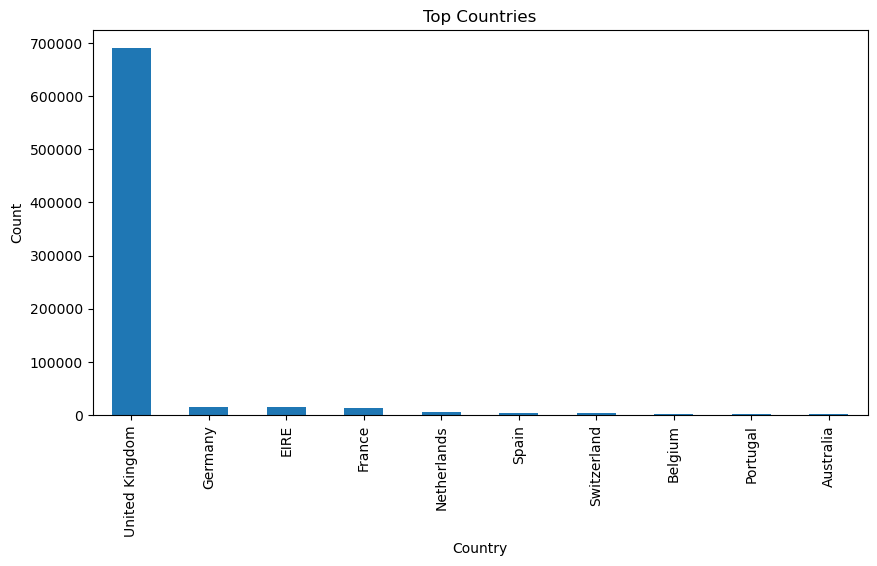

In [167]:
plt.figure(figsize=(10,5))
df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

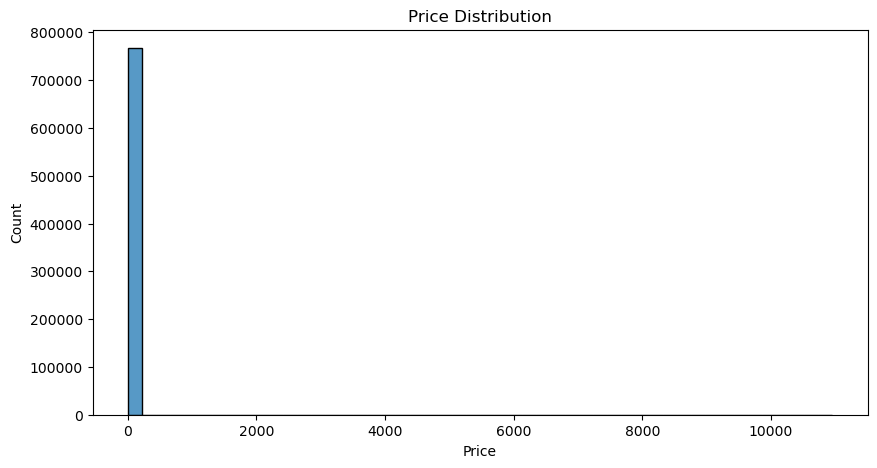

In [168]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=50)

plt.title("Price Distribution")
plt.show()

Save cleaned dataset

In [169]:
df.to_csv("../data/cleaned_online_retail.csv", index=False)

### ***RFM Feature Engineering

In [170]:
df = pd.read_csv("../data/cleaned_online_retail.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [171]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [172]:
# create snapshot date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-05 13:15:00


#### Create RFM table

In [173]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

In [174]:
# rename columns

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,321,12,77556.46
12347.0,35,7,4696.71
12348.0,71,5,2019.40
12349.0,14,4,4428.69
12350.0,305,1,334.40


In [175]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

### Visualize RFM Features

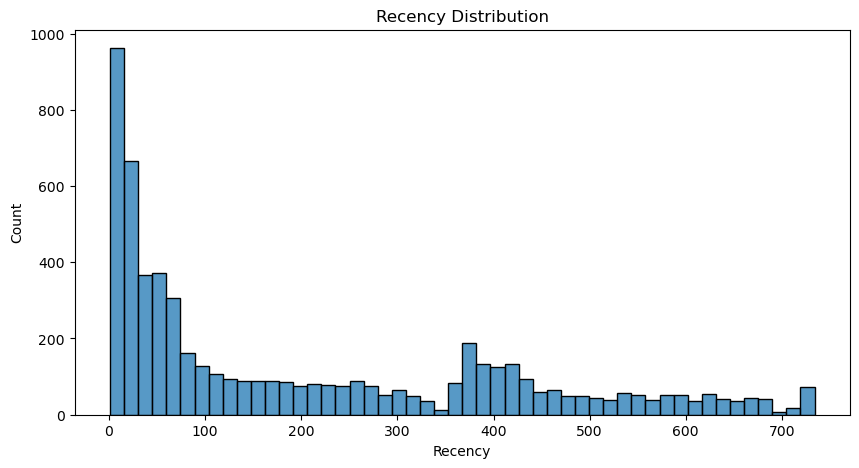

In [176]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Recency'], bins=50)

plt.title("Recency Distribution")
plt.show()

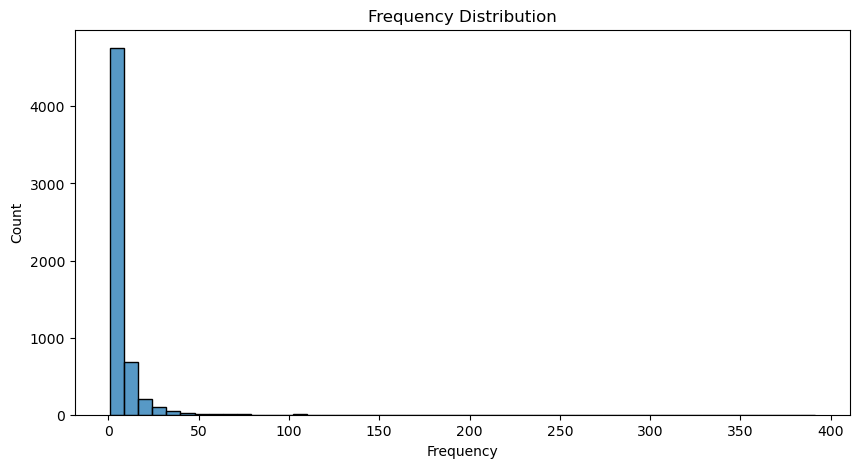

In [177]:
plt.figure(figsize=(10,5))
sns.histplot(rfm['Frequency'], bins=50)

plt.title("Frequency Distribution")
plt.show()

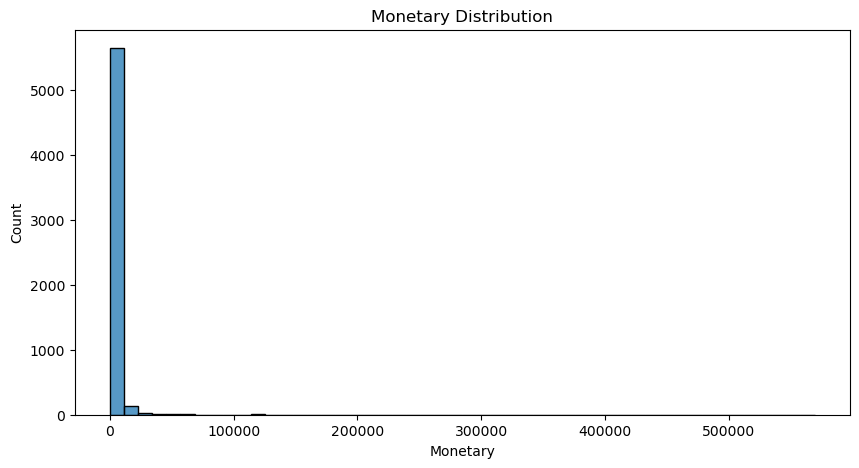

In [178]:
plt.figure(figsize=(10,5))
sns.histplot(rfm['Monetary'], bins=50)

plt.title("Monetary Distribution")
plt.show()

Create Oulier function

In [179]:
def remove_outliers(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

In [180]:
# Outlier removal
rfm = remove_outliers(rfm, 'Monetary')
rfm = remove_outliers(rfm, 'Frequency')
rfm = remove_outliers(rfm, 'Recency')
rfm.shape

(4980, 3)

In [181]:
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

### Feature Scaling

In [182]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [183]:
rfm_scaled

array([[-0.91208359,  1.43660437,  3.6126575 ],
       [-0.74120731,  0.66212104,  0.97955717],
       [-1.01176142,  0.27487937,  3.34906324],
       ...,
       [ 2.03553221, -0.88684562, -0.58654798],
       [ 1.16216457, -0.49960395,  0.26852537],
       [-0.8978439 ,  1.43660437,  3.10742041]])

In [184]:
rfm.to_csv("../data/rfm_data.csv")

### K Means Clustering

In [185]:
### Elbow Method
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

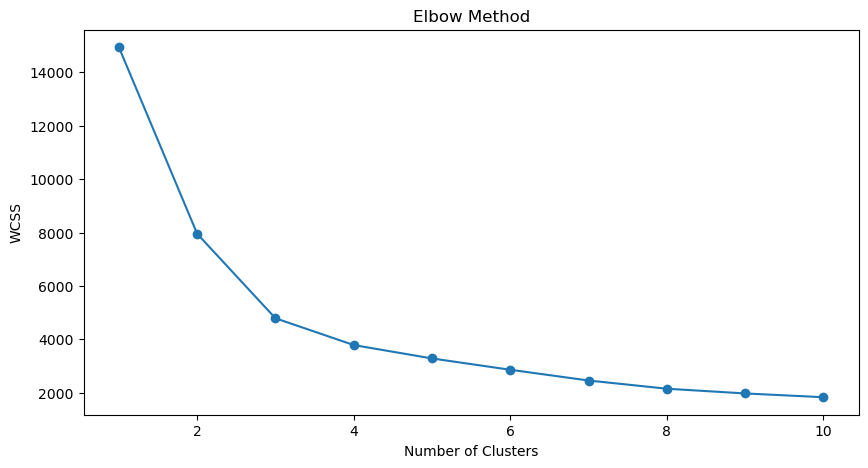

In [186]:
# Elbow plot
plt.figure(figsize=(10,5))

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Train K-Means Model

In [187]:
for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, clusters)
    print(f"K={k}, Score={score}")

K=2, Score=0.45190484250862023
K=3, Score=0.43382395088152303
K=4, Score=0.40653502500120287
K=5, Score=0.35916646733905
K=6, Score=0.37239803921164816
K=7, Score=0.3599489824187217


K = 2 has the highest value.

In [188]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

#assign cluster labels
rfm['Cluster'] = clusters
rfm.head(10)

#check cluster count
rfm['Cluster'].value_counts()

Cluster
0    3607
1    1373
Name: count, dtype: int64

In [189]:
cluster_summary = rfm.groupby('Cluster').mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,279.164680,2.003604,541.178576
1,90.526584,6.670066,2290.226843


### Visualize Clusters with PCA

In [190]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

##### Create PCA Data Frame

In [191]:
pca_df = pd.DataFrame(
    data=pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = clusters
pca_df.head(10)

,PC1,PC2,Cluster
0,3.566583,0.982840,1
1,1.369832,-0.095092,1
2,2.714000,0.478556,1
3,-1.152624,-0.176547,0
4,-1.316646,0.082673,0
5,3.189710,0.577628,1
6,-0.628944,-0.487705,0
7,-0.529844,-0.215178,0
8,-0.322503,-0.240026,0
9,1.678162,0.564694,1


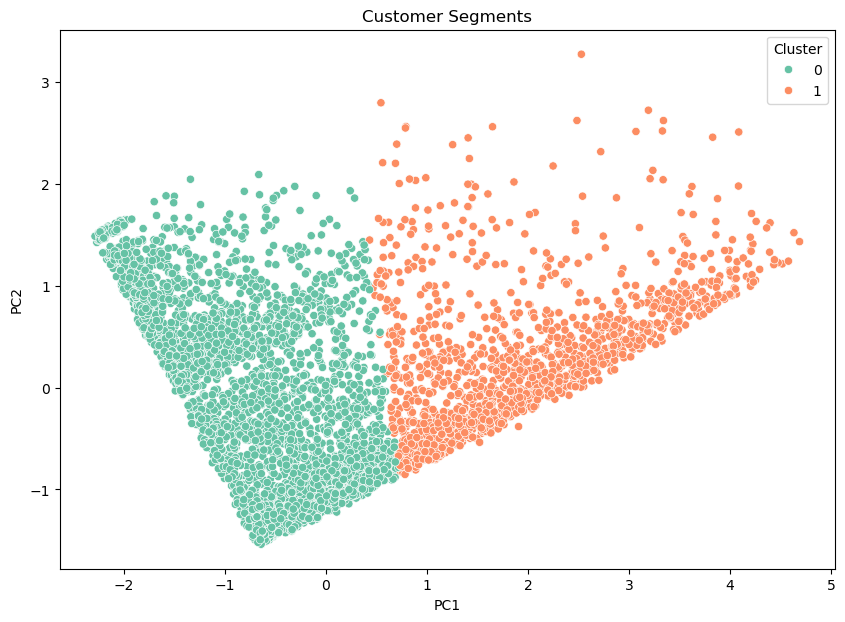

In [192]:
# Plot Customer Clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

In [193]:
# Silhouette Score
score = silhouette_score(rfm_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.45190484250862023


In [194]:
cluster_summary = rfm.groupby('Cluster').mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,279.164680,2.003604,541.178576
1,90.526584,6.670066,2290.226843


In [197]:
cluster_names = {
    0: "Inactive Customers",
    1: "Regular Customers"
}

rfm['CustomerSegment'] = rfm['Cluster'].map(cluster_names)

rfm.head(10)

,Recency,Frequency,Monetary,Cluster,CustomerSegment
Customer ID,,,,,
12347.0,35,7,4696.71,1,Regular Customers
12348.0,71,5,2019.40,1,Regular Customers
12349.0,14,4,4428.69,1,Regular Customers
12350.0,305,1,334.40,0,Inactive Customers
12351.0,370,1,300.93,0,Inactive Customers
12352.0,31,10,2849.84,1,Regular Customers
12353.0,199,2,406.76,0,Inactive Customers
12354.0,228,1,1079.40,0,Inactive Customers
12355.0,209,2,947.61,0,Inactive Customers


Visualize Customer Segmentation

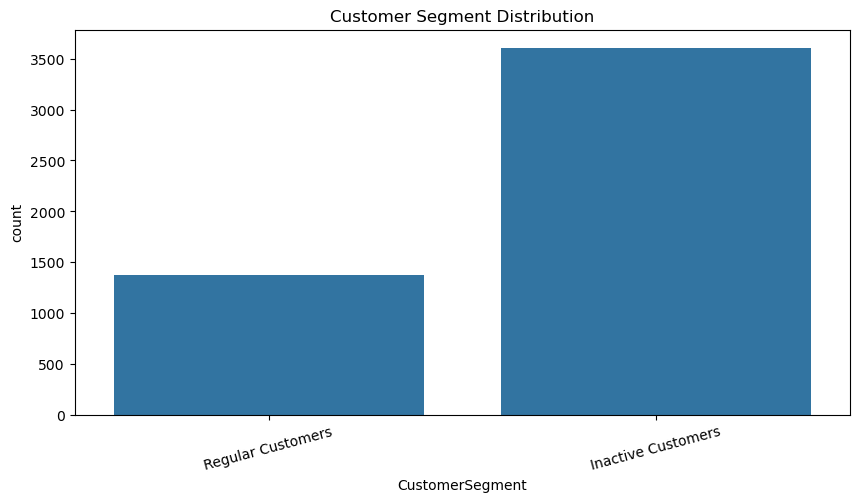

In [198]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='CustomerSegment',
    data=rfm
)

plt.title("Customer Segment Distribution")
plt.xticks(rotation=15)
plt.show()

In [200]:
# save final dataset
rfm.to_csv("../data/customer_segments.csv")